In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
import cartopy.crs as ccrs
from scipy.stats import truncnorm, norm
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [2]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }


In [3]:
'''
d4PDF land-sea mask
'''
dr = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/means'

example = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_winter_1951-2021.nc')
# d4PDF land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/sftlf_fx_d4PDF_HPB_m000_000000-000000.nc')
lsm = lsm.isel(time=0).drop('time')
lsm = lsm.sel(lon = slice(165,180),lat=slice(-48,-33))
lsm = lsm.interp(lat=example.lat,lon=example.lon)

/nesi/project/niwa00015/queenle/seaborn_env/lib/python3.8/site-packages/xarray/coding/times.py:152: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


In [3]:
'''
load mean data
'''

gaussian = {'TA': '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/seasonal/means/d4PDF_scen_seasongoeshere_TA_gaussian_ensMean.nc',
            'ROF':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/ROF/seasonal/means/d4PDF_scen_seasongoeshere_ROF_gaussian_ensMean.nc',
'PRECIPI':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/PRECIPI/seasonal/full/means/PRECIPI_Amon_d4PDF_scen_FullEnsMean_gaussian_seasongoeshere_1951-2021.nc'}

raw = {'TA': '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/TA/full/means/TA_Amon_d4PDF_scen_FullEnsMean_raw_seasongoeshere_1951-2021.nc',
            'ROF':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/means/ROF_Amon_d4PDF_scen_FullEnsMean_raw_seasongoeshere_1951-2021.nc',
            'PRECIPI':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/PRECIPI/full/means/PRECIPI_Amon_d4PDF_scen_FullEnsMean_raw_seasongoeshere_1951-2021.nc'}

gaussian_das = {}
for key in gaussian:
    st = gaussian[key]
    if key in ['TA','ROF']:
        st = st.split('scen')[0] + 'all' + st.split('scen')[1]

    else:
        st = st.split('scen')[0] + 'HPB' + st.split('scen')[1]
        
    for season in ['winter','summer']:
        st2 = st.split('seasongoeshere')[0] + season + st.split('seasongoeshere')[1]
        da = xr.open_dataarray(st2)
    
        gaussian_das[f'{key}_{season}'] = da

raw_das = {}
for key in raw:
    st = raw[key]
    st = st.split('scen')[0] + 'HPB' + st.split('scen')[1]

    for season in ['winter','summer']:
        st2 = st.split('seasongoeshere')[0] + season + st.split('seasongoeshere')[1]
        da = xr.open_dataarray(st2)
    
        raw_das[f'{key}_{season}'] = da

In [4]:
'''
load ensemble data
'''

gaussian_files = {'TA': '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/seasonal/d4PDF_scen_seasongoeshere_TA_gaussian',
            'ROF':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/ROF/seasonal/perturbed/d4PDF_scen_seasongoeshere_ROF_gaussian',
            'PRECIPI':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/PRECIPI/seasonal/d4PDF_scen_seasongoeshere_PRECIPI_gaussian'}

raw_files = {'TA':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/TA/full/TA_Amon_d4PDF_scen_ensMEM_raw_seasongoeshere_1951-2021.nc',
            'ROF':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/ROF_Amon_d4PDF_scen_ensMEM_raw_seasongoeshere_1951-2021.nc',
            'PRECIPI':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/PRECIPI/full/PRECIPI_Amon_d4PDF_scen_ensMEM_raw_seasongoeshere_1951-2021.nc'}


def load_gaussian_ensemble(var,season):
    
    da_list = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
        st = gaussian_files[var]
        st = st.split('scen')[0] + 'all' + st.split('scen')[1] + f'_m{number}.nc'

        st2 = st.split('seasongoeshere')[0] + season + st.split('seasongoeshere')[1]
        da = xr.open_dataarray(st2)
        da.name = f'm{number}'
        
        da_list.append(da)
        
    # Extract names for the new dimension
    names = [da.name for da in da_list]

    # Concatenate along a new dimension 'name'
    ds = xr.concat(da_list, dim=pd.Index(names, name='ensemble_member'))
    ds.name = f'{var}_{season}'
    return(ds)


def load_raw_ensemble(var,season,local_mean_removed=False):

    da_list = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
        
        st = raw_files[var]
        st = st.split('scen')[0] + 'HPB' + st.split('scen')[1]
        st2 = st.split('seasongoeshere')[0] + season + st.split('seasongoeshere')[1]
        st3 = st2.split('ensMEM')[0] + f'm{number}' + st2.split('ensMEM')[1]
        
        da = xr.open_dataarray(st3)
        
        if local_mean_removed:
            da = da - da.mean('time')
            
        da.name = f'm{number}'
        
        da_list.append(da)
        
    # Extract names for the new dimension
    names = [da.name for da in da_list]

    # Concatenate along a new dimension 'name'
    ds = xr.concat(da_list, dim=pd.Index(names, name='ensemble_member'))
    ds.name = f'{var}_{season}'
    return(ds)


gaussian_ensembles = {}
raw_ensembles = {}
lmr_ensembles = {}

for var in ['TA','ROF','PRECIPI']:
    for season in ['winter','summer']:
        gaussian_ensembles[f'{var}_{season}'] = load_gaussian_ensemble(var,season)
        raw_ensembles[f'{var}_{season}'] = load_raw_ensemble(var,season,local_mean_removed=False)
        lmr_ensembles[f'{var}_{season}'] = load_raw_ensemble(var,season,local_mean_removed=True)
        

In [5]:
def get_dist(n,mu,sigma):

    # Effective bounds in the normal distribution
    lower_quantile = 1 / (n + 1)
    upper_quantile = n / (n + 1)

    # Corresponding z-scores
    a = norm.ppf(lower_quantile)
    b = norm.ppf(upper_quantile)

    # Define truncated normal distribution
    trunc_dist = truncnorm(a=a, b=b, loc=mu, scale=sigma)
    
    return(trunc_dist)

TA
PRECIPI
ROF


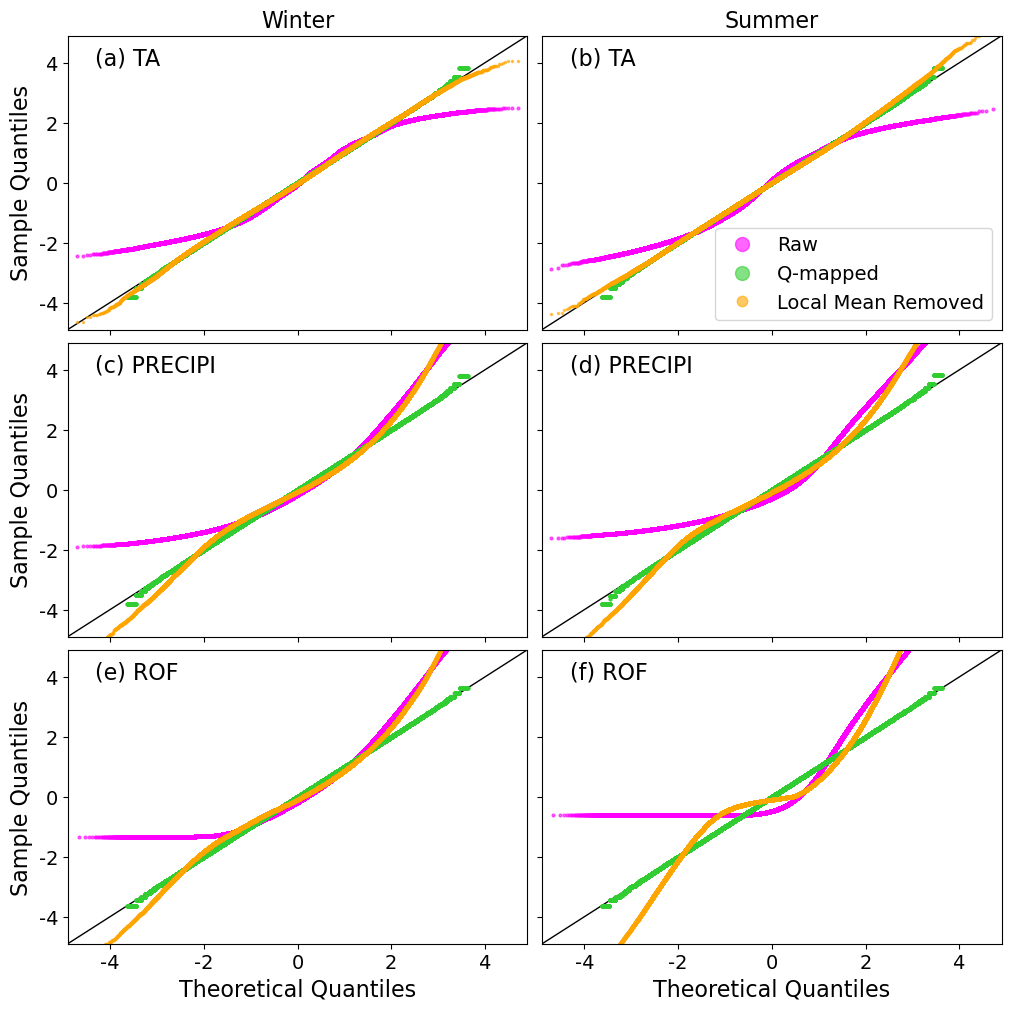

In [26]:
'''
plot raw and gaussian time series for each ensemble member
'''

y_labels = {'TA':['normalized','Kelvin'],
         'PRECIPI':['normalized','kg/m2/s'],
         'ROF':['normalized','kg/m2/s']}

var_names = {'TA':'Temperature','PRECIPI':'Precipitation','ROF':'Runoff'}
s_names = {'winter':'Winter','summer':'Summer'}

fig,axs = plt.subplots(3,2, figsize=(10,10),sharex=True,sharey=True,layout='constrained')
  
labels = [['(a)','(b)',],
          ['(c)','(d)',],
          ['(e)','(f)',]]

# n = 72 years x 100 members
trunc_dist = get_dist(7200,0,1)
for i,var in enumerate(['TA','PRECIPI','ROF']):
    print(var)

    for j,season in enumerate(['winter','summer']):

        ax = axs[i][j]
        
        gaussian = gaussian_ensembles[f'{var}_{season}']
        gaussian = gaussian_ensembles[f'{var}_{season}'].data.flatten()
        gaussian = gaussian[~np.isnan(gaussian)]
        gaussian = gaussian[np.isfinite(gaussian)]

        raw = raw_ensembles[f'{var}_{season}'].data.flatten()
        raw = raw[~np.isnan(raw)]
        
        lmr = lmr_ensembles[f'{var}_{season}'].data.flatten()
        lmr = lmr[~np.isnan(lmr)]
        
        sm.qqplot(ax=ax,data=raw,label='Raw',line='45',fit=True,marker='.', markerfacecolor='magenta', markeredgecolor='magenta',alpha=0.6,markersize=4)
        sm.qqplot(ax=ax,data=gaussian,dist=trunc_dist,label='Q-mapped',fit=False,marker='.', markerfacecolor='limegreen', markeredgecolor='limegreen',alpha=0.6,markersize=4)
        sm.qqplot(ax=ax,data=lmr,label='Local Mean Removed',fit=True,marker='.', markerfacecolor='orange', markeredgecolor='orange',alpha=0.6,markersize=3)
            
        ax.get_lines()[1].set_color("black")
        ax.get_lines()[1].set_linewidth("1")

        ax.set_ylabel(f'{var_names[var]}\n{y_labels[var][0]}' if j == 0 else '',fontdict=font)
        ax.set_title(s_names[season] if i == 0 else '',fontdict=font)
        ax.set_xlabel('Theoretical Quantiles' if i == 2 else '',fontdict=font)
        
        ax.text(0.06,0.9,f'{labels[i][j]} {var}',fontdict=font,ha='left',transform=axs[i][j].transAxes)
        
        if j == 0:
            ax.set_ylabel('Sample Quantiles')
            ax.set_yticks([-4,-2,0,2,4],labels=['-4','-2','0','2','4'],fontsize=14)
        else:
            ax.set_ylabel('')

        if i == 2:
            ax.set_xticks([-4,-2,0,2,4],labels=['-4','-2','0','2','4'],fontsize=14)


axs[0][1].legend(loc='lower right',fontsize=14, markerscale=5)
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/qq_plot.png',dpi=300)


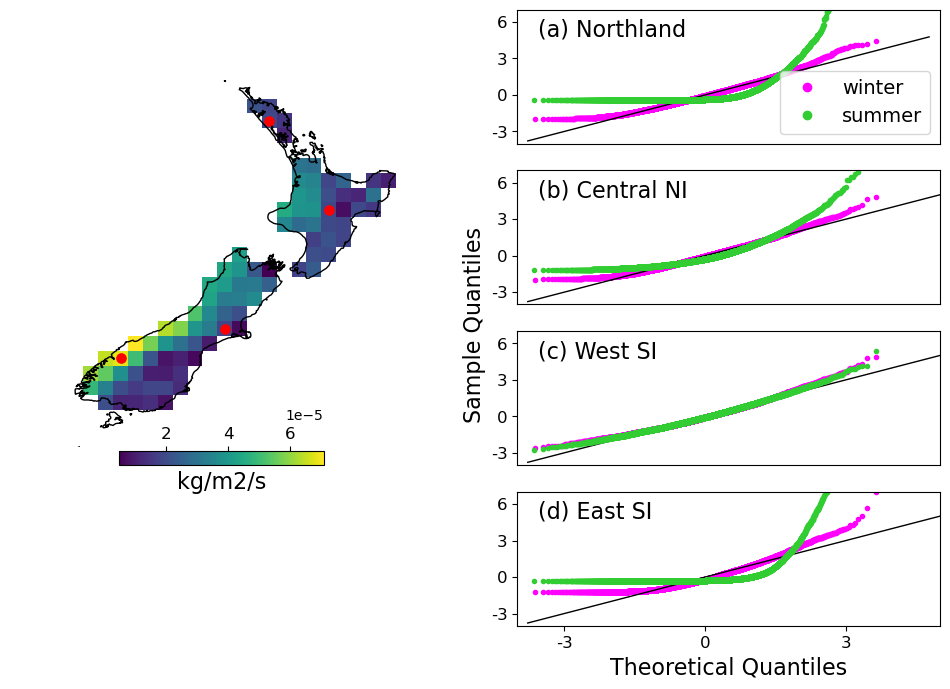

In [40]:
locations = {'East SI':[-43.5,172],'West SI':[-44.5,168],'Central NI':[-39,176],'Northland':[-35.5,174]}

fig = plt.figure(figsize=(12,8))#, layout="constrained")
gs = fig.add_gridspec(4, 2)

# MAP PLOT
ax0 = fig.add_subplot(gs[:3, 0],projection=ccrs.PlateCarree())
im = example.isel(time=0).plot(ax=ax0,transform=ccrs.PlateCarree(),add_colorbar=False)
for loc in locations:
    ts = example.sel(lat=locations[loc][0],lon=locations[loc][1],method='nearest')
    lat = ts.lat.data
    lon = ts.lon.data
    ax0.scatter(lon,lat,color='red',s=44,transform=ccrs.PlateCarree())
    
ax0.coastlines()
ax0.set_extent([164,180, -48,-33])
ax0.set_title('')
ax0.axis('off')

# Add a horizontal colorbar manually
cbar = fig.colorbar(im, ax=ax0, orientation='horizontal', fraction=0.03, pad=0.01, aspect=15)
cbar.ax.xaxis.set_ticks_position("top")

# Make the colorbar shorter than the plot
cbar.ax.tick_params(labelsize=12)  # Set font size of ticks

# Set a custom label
cbar.set_label('kg/m2/s', fontsize=16)


# QQ PLOTS
axs = [fig.add_subplot(gs[0,1]),fig.add_subplot(gs[1,1]),fig.add_subplot(gs[2,1]),fig.add_subplot(gs[3,1])]

colors = ['magenta','limegreen']
var = 'ROF'
labels = ['(a)','(b)','(c)','(d)']
for i,loc in enumerate(['Northland','Central NI','West SI','East SI']):

    ax = axs[i]
    
    for j,s in enumerate(['winter','summer']):
    
        #season = raw_das[f'{var}_{s}']
        season = raw_ensembles[f'{var}_{s}']
        #raw = raw[~np.isnan(raw)]
        
        ts = season.sel(lat=locations[loc][0],lon=locations[loc][1],method='nearest')
        ts = ts.data.flatten()
        ts = ts[~np.isnan(ts)]
    
        sm.qqplot(ax=ax,data=ts,label=s,line='45'if j==0 else None,fit=True,marker='.', markerfacecolor=colors[j], markeredgecolor=colors[j],alpha=1,markersize=6)

    ax.get_lines()[1].set_color("black")
    ax.get_lines()[1].set_linewidth("1")

    ax.text(0.05,0.8,f'{labels[i]} {loc}',fontdict=font,ha='left',transform=ax.transAxes)

    ax.set_ylabel('')
    ax.set_yticks([-3,0,3,6],labels=['-3','0','3','6'],fontsize=12)

    ax.set_xlim(-4,5)
    ax.set_ylim(-4,7)

    if i == 3:
        ax.set_xlabel('Theoretical Quantiles',fontsize=16)
        ax.set_xticks([-3,0,3],labels=['-3','0','3'],fontsize=12)
    else:
        ax.set_xlabel('')
        ax.set_xticks([])

axs[0].legend(loc='lower right',fontsize=14, markerscale=2)
axs[0].text(-0.1,1.555,'Sample Quantiles',fontdict=font,ha='center',rotation=90,transform=ax.transAxes)

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/select_cell_qq_plots.png',dpi=300)


In [ ]:
'''
plot raw and gaussian time series for each ensemble member
'''

y_labels = {'TA':['normalized','Kelvin'],
         'PRECIPI':['normalized','kg/m2/s'],
         'ROF':['normalized','kg/m2/s']}

var_names = {'TA':'Temperature','PRECIPI':'Precipitation','ROF':'Runoff'}
s_names = {'winter':'Winter','summer':'Summer'}

fig,axs = plt.subplots(3,2, figsize=(10,10),sharex=True,sharey=True,layout='constrained')
  
labels = [['(a)','(b)',],
          ['(c)','(d)',],
          ['(e)','(f)',]]

for i,var in enumerate(['TA','PRECIPI','ROF']):

    for j,season in enumerate(['winter','summer']):

        ax = axs[i][j]
        
        gaussian = gaussian_ensembles[f'{var}_{season}'].data.flatten()
        gaussian = gaussian[~np.isnan(gaussian)]
        
        raw = raw_ensembles[f'{var}_{season}'].data.flatten()
        raw = raw[~np.isnan(raw)]
        
        lmr = lmr_ensembles[f'{var}_{season}'].data.flatten()
        lmr = lmr[~np.isnan(lmr)]
        

        sm.qqplot(ax=ax,data=raw,label='Raw',line='45',fit=True,marker='.', markerfacecolor='magenta', markeredgecolor='magenta',alpha=0.6,markersize=4)
        sm.qqplot(ax=ax,data=gaussian,label='Q-mapped',fit=True,marker='.', markerfacecolor='limegreen', markeredgecolor='limegreen',alpha=0.6,markersize=4)
        sm.qqplot(ax=ax,data=lmr,label='Local Mean Removed',fit=True,marker='.', markerfacecolor='orange', markeredgecolor='orange',alpha=0.6,markersize=4)

        ax.get_lines()[1].set_color("black")
        ax.get_lines()[1].set_linewidth("1")

        ax.set_ylabel(f'{var_names[var]}\n{y_labels[var][0]}' if j == 0 else '',fontdict=font)
        ax.set_title(s_names[season] if i == 0 else '',fontdict=font)
        ax.set_xlabel('Theoretical Quantiles' if i == 2 else '',fontdict=font)
        
        ax.text(0.06,0.9,f'{labels[i][j]} {var}',fontdict=font,ha='left',transform=axs[i][j].transAxes)
        
        if j == 0:
            ax.set_ylabel('Sample Quantiles')
            ax.set_yticks([-3,-2,-1,0,1,2,3],labels=['-3','-2','-1','0','1','2','3'],fontsize=14)
        else:
            ax.set_ylabel('')

        if i == 2:
            ax.set_xticks([-3,-2,-1,0,1,2,3],labels=['-3','-2','-1','0','1','2','3'],fontsize=14)


axs[0][1].legend(loc='lower right',fontsize=14, markerscale=5)
#plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/qq_plot.png',dpi=300)


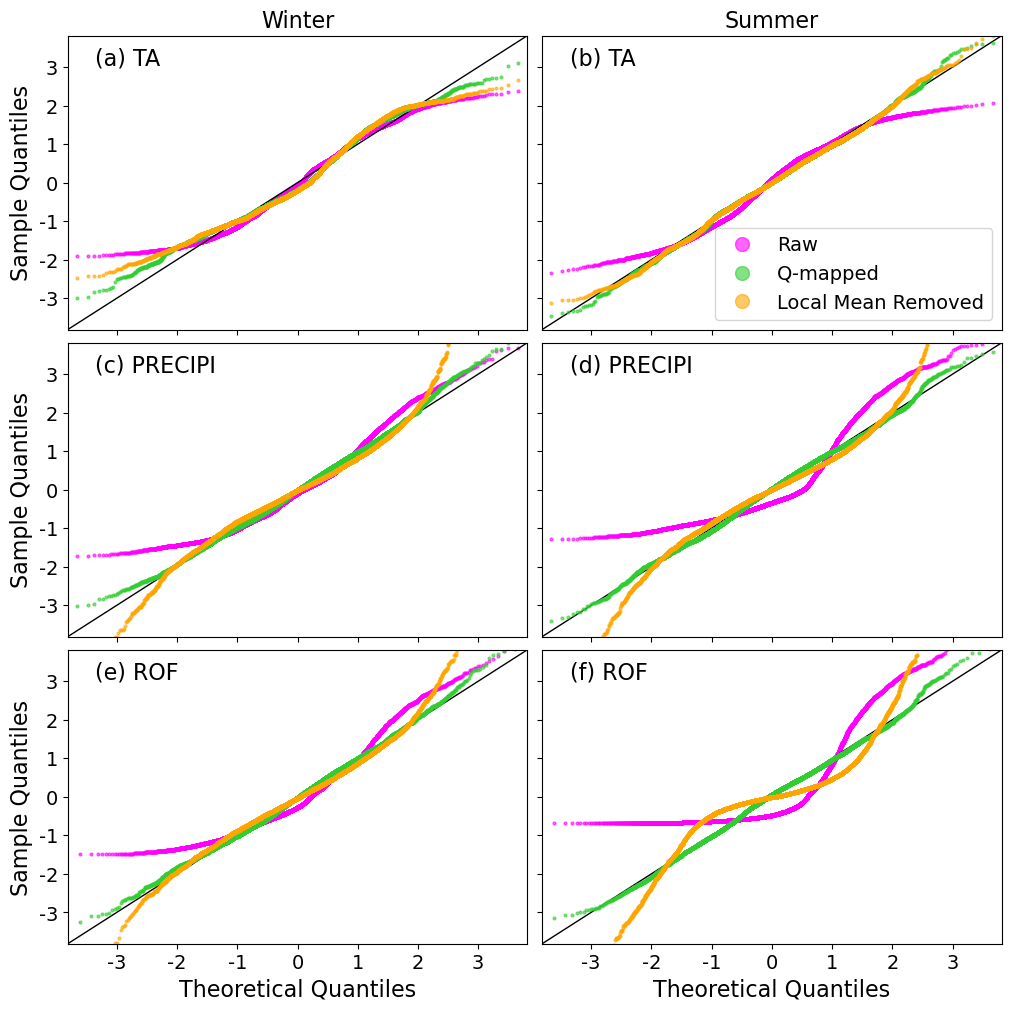

In [50]:
'''
plot raw and gaussian time series for each ensemble member
'''

y_labels = {'TA':['normalized','Kelvin'],
         'PRECIPI':['normalized','kg/m2/s'],
         'ROF':['normalized','kg/m2/s']}

var_names = {'TA':'Temperature','PRECIPI':'Precipitation','ROF':'Runoff'}
s_names = {'winter':'Winter','summer':'Summer'}

fig,axs = plt.subplots(3,2, figsize=(10,10),sharex=True,sharey=True,layout='constrained')
  
labels = [['(a)','(b)',],
          ['(c)','(d)',],
          ['(e)','(f)',]]

for i,var in enumerate(['TA','PRECIPI','ROF']):

    for j,season in enumerate(['winter','summer']):

        ax = axs[i][j]
        
        gaussian = gaussian_das[f'{var}_{season}'].data.flatten()
        gaussian = gaussian[~np.isnan(gaussian)]
        raw = raw_das[f'{var}_{season}']
        norm = raw - raw.mean('time')

        norm = norm.data.flatten()
        norm = norm[~np.isnan(norm)]
        
        raw = raw.data.flatten()
        raw = raw[~np.isnan(raw)]

        sm.qqplot(ax=ax,data=raw,label='Raw',line='45',fit=True,marker='.', markerfacecolor='magenta', markeredgecolor='magenta',alpha=0.6,markersize=4)
        sm.qqplot(ax=ax,data=gaussian,label='Q-mapped',fit=True,marker='.', markerfacecolor='limegreen', markeredgecolor='limegreen',alpha=0.6,markersize=4)
        sm.qqplot(ax=ax,data=norm,label='Local Mean Removed',fit=True,marker='.', markerfacecolor='orange', markeredgecolor='orange',alpha=0.6,markersize=4)

        ax.get_lines()[1].set_color("black")
        ax.get_lines()[1].set_linewidth("1")

        ax.set_ylabel(f'{var_names[var]}\n{y_labels[var][0]}' if j == 0 else '',fontdict=font)
        ax.set_title(s_names[season] if i == 0 else '',fontdict=font)
        ax.set_xlabel('Theoretical Quantiles' if i == 2 else '',fontdict=font)
        
        ax.text(0.06,0.9,f'{labels[i][j]} {var}',fontdict=font,ha='left',transform=axs[i][j].transAxes)
        
        if j == 0:
            ax.set_ylabel('Sample Quantiles')
            ax.set_yticks([-3,-2,-1,0,1,2,3],labels=['-3','-2','-1','0','1','2','3'],fontsize=14)
        else:
            ax.set_ylabel('')

        if i == 2:
            ax.set_xticks([-3,-2,-1,0,1,2,3],labels=['-3','-2','-1','0','1','2','3'],fontsize=14)


axs[0][1].legend(loc='lower right',fontsize=14, markerscale=5)
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/qq_plot.png',dpi=300)


Text(-0.1, 1.555, 'Sample Quantiles')

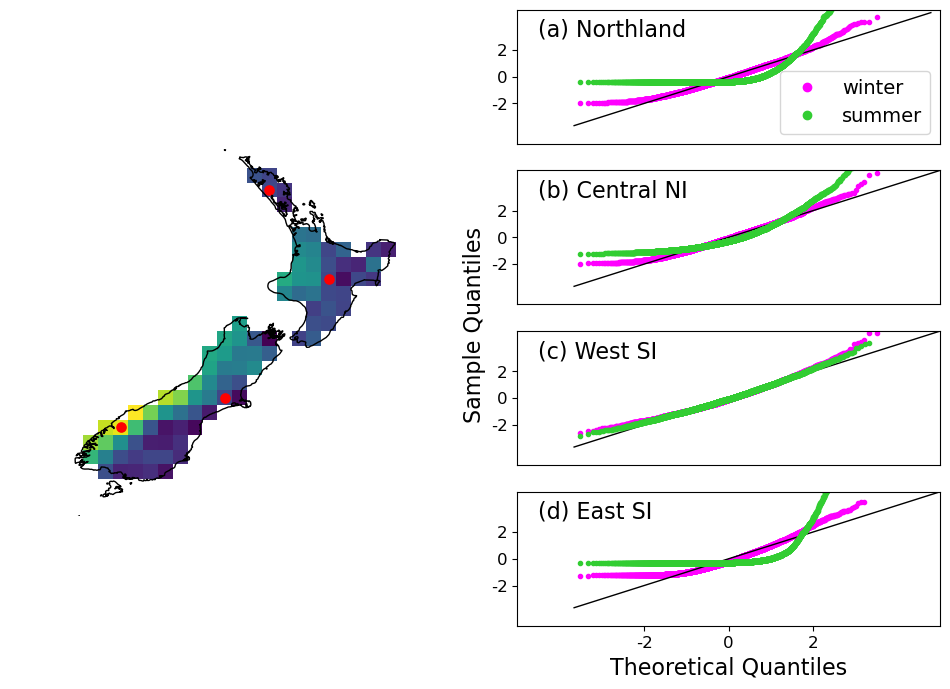

In [72]:
'''
load single member data
'''

gaussian = {'TA': '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/TA/seasonal/d4PDF_scen_seasongoeshere_TA_gaussian_m001.nc',
            'ROF':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/ROF/seasonal/d4PDF_scen_seasongoeshere_ROF_gaussian_m001.nc',
            'PRECIPI':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/PRECIPI/seasonal/d4PDF_scen_seasongoeshere_PRECIPI_gaussian_m001.nc'}

raw = {'TA': '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/TA/full/TA_Amon_d4PDF_scen_m001_raw_seasongoeshere_1951-2021.nc',
            'ROF':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/ROF_Amon_d4PDF_scen_m001_raw_seasongoeshere_1951-2021.nc',
            'PRECIPI':'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/PRECIPI/full/PRECIPI_Amon_d4PDF_scen_m001_raw_seasongoeshere_1951-2021.nc'}

gaussian_das = {}
for key in gaussian:
    st = gaussian[key]
    st = st.split('scen')[0] + 'all' + st.split('scen')[1]

    for season in ['winter','summer']:
        st2 = st.split('seasongoeshere')[0] + season + st.split('seasongoeshere')[1]
        da = xr.open_dataarray(st2)
    
        gaussian_das[f'{key}_{season}'] = da
        
raw_das = {}
for key in raw:
    st = raw[key]
    st = st.split('scen')[0] + 'HPB' + st.split('scen')[1]

    for season in ['winter','summer']:
        st2 = st.split('seasongoeshere')[0] + season + st.split('seasongoeshere')[1]
        da = xr.open_dataarray(st2)
    
        raw_das[f'{key}_{season}'] = da

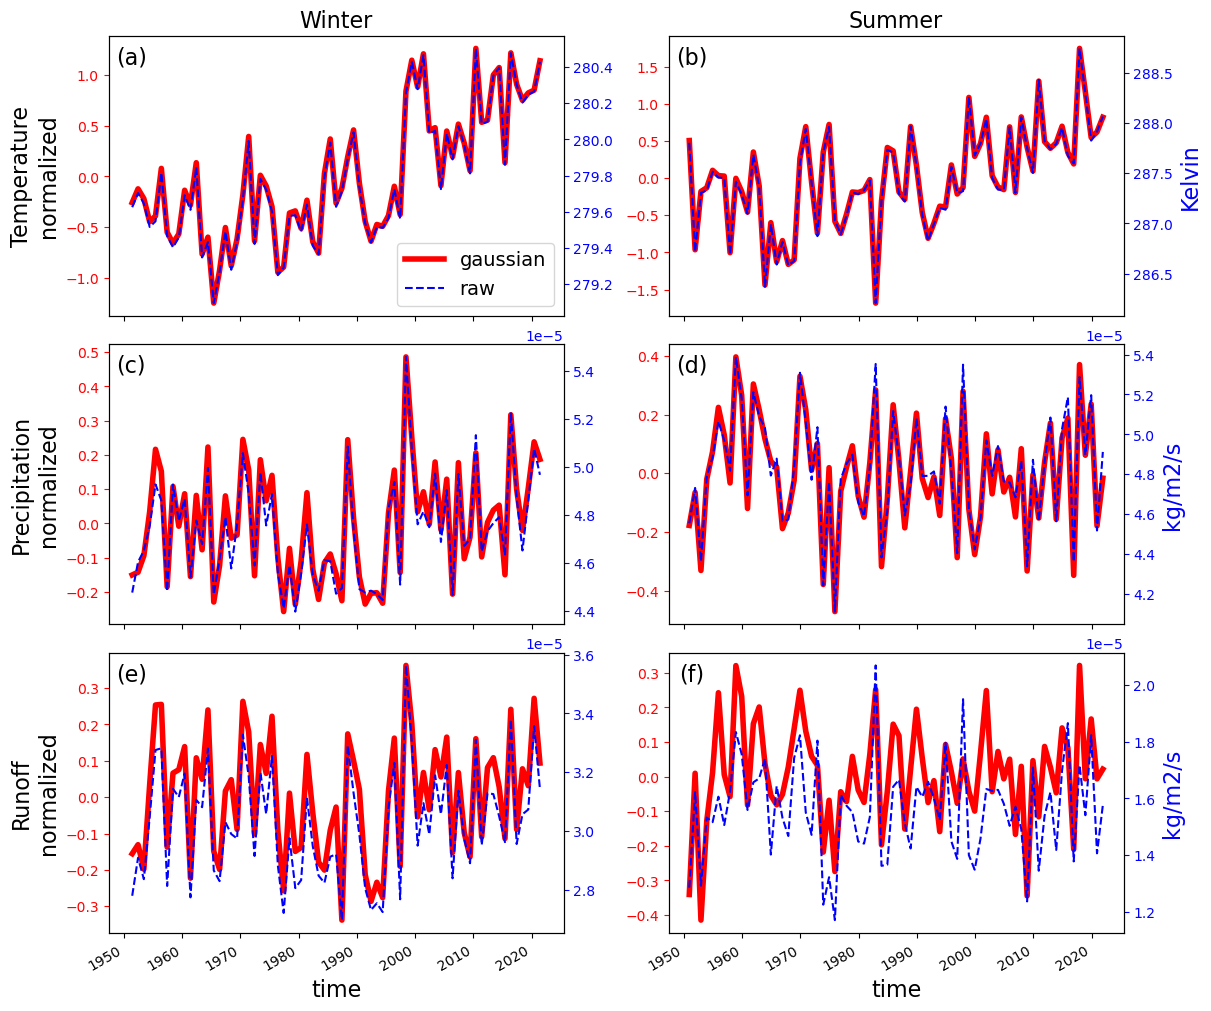

In [78]:
'''
plot raw and gaussian time series for each ensemble member
'''

y_labels = {'TA':['normalized','Kelvin'],
         'PRECIPI':['normalized','kg/m2/s'],
         'ROF':['normalized','kg/m2/s']}

var_names = {'TA':'Temperature','PRECIPI':'Precipitation','ROF':'Runoff'}
s_names = {'winter':'Winter','summer':'Summer'}

fig,axs = plt.subplots(3,2, figsize=(12,10),sharex=True,layout='constrained')
  
labels = [['(a)','(b)',],
          ['(c)','(d)',],
          ['(e)','(f)',]]

for i,var in enumerate(['TA','PRECIPI','ROF']):

    for j,season in enumerate(['winter','summer']):

        gaussian = gaussian_das[f'{var}_{season}']
        raw = raw_das[f'{var}_{season}']
        
        twin_ax = ax=axs[i][j].twinx()

        ln1 = gaussian.mean(['lat','lon']).plot(ax=axs[i][j],c='red',linewidth=4,label='gaussian')
        ln2 = raw.mean(['lat','lon','lev']).plot(ax=twin_ax,c='blue',linestyle='--',label='raw')

        axs[i][j].set_ylabel(f'{var_names[var]}\n{y_labels[var][0]}' if j == 0 else '',fontdict=font)
        axs[i][j].set_title(s_names[season] if i == 0 else '',fontdict=font)
        axs[i][j].set_xlabel('time' if i == 2 else '',fontdict=font)
        
        twin_ax.set_ylabel(y_labels[var][1] if j == 1 else '',fontdict=font)
        
        if i == 0 and j == 0:
            lns = ln1+ln2
            labs = [l.get_label() for l in lns]
            axs[i][j].legend(lns, labs, loc='lower right',fontsize=14)

        #twin_ax.spines['right'].set_color('blue')
        twin_ax.yaxis.label.set_color('blue')
        twin_ax.tick_params(axis='y', colors='blue')
        
        #axs[i][j].yaxis.label.set_color('red')
        axs[i][j].tick_params(axis='y', colors='red')
        axs[i][j].text(0.05,0.9,labels[i][j],fontdict=font,ha='center',transform=axs[i][j].transAxes)

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/quantile_mapping_figure.png',dpi=300)
